In [33]:
import os
import h5py 
import numpy as np

import matplotlib.pyplot as plt
from pathlib import Path

import tifffile as tiff

In [7]:
file1 = Path("../data/CT_Hys/patch_000_super-res.h5")
file2 = Path("../data/CT_Hys/patch_000.h5")

assert os.path.exists(file1), os.path.exists(file2)

In [27]:
data = {}
with h5py.File(file1,"r") as F:
    data["super_res"] = F["volume"][0,0,::]

with h5py.File(file2,"r") as F:
    data["original"] = F["patch"][0,::]
    data["low_res"] = F["patch_lr"][0,::]

In [19]:
for key, item in data.items():
    print(f"{key}: {item.shape}, {item.min()}, {item.max()}")

super_res: (128, 128, 128), 4113.0, 6383.0
original: (128, 128, 128), 3207.0, 7599.0
low_res: (32, 32, 32), 3554.875, 6953.625


In [28]:
x = data["low_res"]
lo = float(np.percentile(x, 1.0))
hi = float(np.percentile(x, 99.0))

print(f"low {lo}, high {hi}")

low 4216.375, high 6277.666015625


In [29]:
x = data["super_res"]

x = (x + 1.0) * 0.5 * (hi - lo) + lo

data["super_res"] = x

In [30]:
import torch
import torch.nn.functional as F

x_lr = torch.tensor(data["low_res"])

if x_lr.ndim == 3:
    x_lr = x_lr.unsqueeze(0).unsqueeze(0)   # [1,1,D,H,W]
elif x_lr.ndim == 4:
    x_lr = x_lr.unsqueeze(0)                # [1,C,D,H,W]

x_hr = F.interpolate(
    x_lr,
    scale_factor=4,
    mode="trilinear",
    align_corners=False
)

# back to [D,H,W] if you want
x_hr = x_hr.squeeze(0).squeeze(0)

data["up_scale"] = x_hr

Text(0.5, 1.0, 'up_scale (tri-linear)')

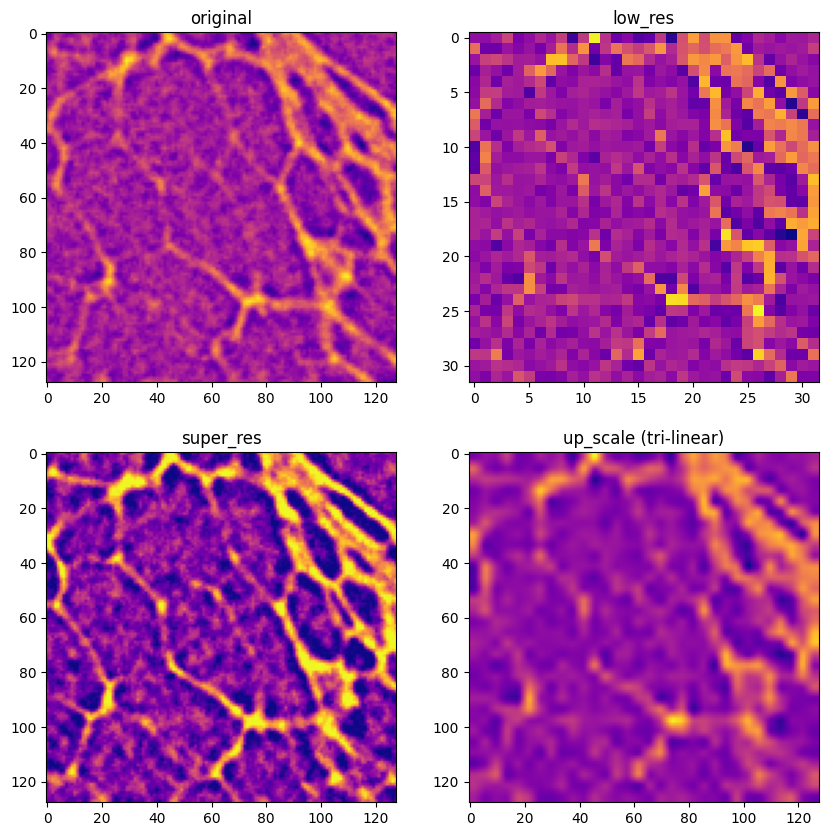

In [50]:
fig, axs = plt.subplots(2,2,figsize= (10,10))


n = 10 

axs[0][0].imshow(data["original"][n*4-1,::],cmap="plasma")
axs[0][0].set_title("original")
axs[0][1].imshow(data["low_res"][n-1,::],cmap="plasma")
axs[0][1].set_title("low_res")

axs[1][0].imshow(data["super_res"][n*4-1,::],cmap="plasma")
axs[1][0].set_title("super_res")

axs[1][1].imshow(data["up_scale"][n*4-1,::],cmap="plasma")
axs[1][1].set_title("up_scale (tri-linear)")



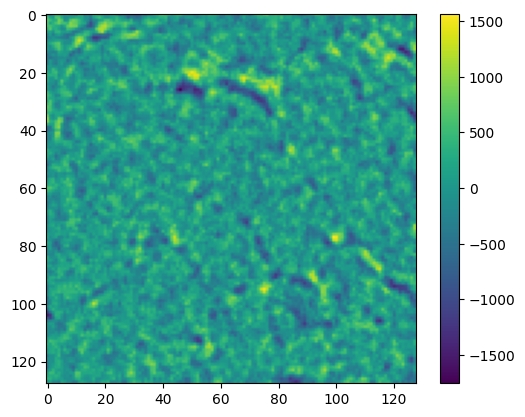

In [41]:
plt.imshow(data["original"][0,::]-data["super_res"][0,::])
plt.colorbar()

In [36]:
def save_volumes_as_tiff_slices(
    data: dict,
    out_root: str,
    batch_idx: int = 0,
    channel_idx: int = 0,
    scale_to_uint16: bool = True,
):
    """
    data: dict of tensors or numpy arrays
          keys like 'super_res', 'original', 'up_scale', 'low_res'
    Saves:
      out_root/
        super_res/
          slice_0000.tif
          slice_0001.tif
          ...
        low_res/
        ...
    """
    os.makedirs(out_root, exist_ok=True)

    for key, vol in data.items():
        print(f"Saving '{key}'")

        # --- tensor → numpy ---
        if hasattr(vol, "detach"):
            vol = vol.detach().cpu().numpy()

        # Handle shapes
        # [B,C,Z,Y,X] → [Z,Y,X]
        if vol.ndim == 5:
            vol = vol[batch_idx, channel_idx]
        # [B,Z,Y,X] → [Z,Y,X]
        elif vol.ndim == 4:
            vol = vol[batch_idx]
        elif vol.ndim == 3:
            vol = vol
        else:
            raise ValueError(f"Unsupported shape for '{key}': {vol.shape}")

        Z = vol.shape[0]

        out_dir = os.path.join(out_root, key)
        os.makedirs(out_dir, exist_ok=True)

        # Optional rescaling
        if scale_to_uint16:
            vmin, vmax = vol.min(), vol.max()
            if vmax > vmin:
                vol_u16 = ((vol - vmin) / (vmax - vmin) * 65535.0).astype(np.uint16)
            else:
                vol_u16 = np.zeros_like(vol, dtype=np.uint16)
        else:
            vol_u16 = vol

        # --- save slice-by-slice ---
        for z in range(Z):
            tiff.imwrite(
                os.path.join(out_dir, f"slice_{z:04d}.tif"),
                vol_u16[z],
            )

        print(f"  → {Z} slices written to {out_dir}")

In [37]:
save_volumes_as_tiff_slices(
    data,
    out_root="out",
    batch_idx=0,
    channel_idx=0,
    scale_to_uint16=True,
)

Saving 'super_res'
  → 128 slices written to out/super_res
Saving 'original'
  → 128 slices written to out/original
Saving 'low_res'
  → 32 slices written to out/low_res
Saving 'up_scale'
  → 128 slices written to out/up_scale
